Standardization (in Machine Learning) is a data preprocessing technique used to rescale features so they have:

Mean = 0
Standard deviation = 1

In [45]:
import numpy as np #linear algebra
import pandas as pd #data processing
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [47]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [48]:
df=df.iloc[:,2:]

In [49]:
df.sample(5)

,Age,EstimatedSalary,Purchased
66,24,19000,0
73,33,113000,0
314,39,79000,0
257,40,57000,0
148,29,61000,0


Train Test Split

Original Data

   ↓

Create indices
 [0...n]
   ↓

Shuffle indices 🎲

   ↓

Split indices (70% / 30%)

   ↓

Apply to X and y

   ↓
   
X_train, X_test, y_train, y_test

In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Purchased',axis=1),
                                                 df['Purchased'],
                                                 test_size=0.3,
                                                 random_state=0)
X_train.shape, X_test.shape

((280, 2), (120, 2))

Standard Scaler

In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #create object

scaler.fit(X_train) #learn mean and SD
X_train_scaled = scaler.transform(X_train) #apply
X_test_scaled = scaler.transform(X_test) #apply for x test data

scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [52]:
X_train_scaled
X_test_scaled

array([[-0.77101313,  0.49720103],
       [ 0.0133054 , -0.57280368],
       [-0.28081405,  0.15017248],
       [-0.77101313,  0.26584866],
       [-0.28081405, -0.57280368],
       [-1.06513258, -1.44037507],
       [-0.67297331, -1.5849703 ],
       [-0.18277423,  2.14558666],
       [-1.94749093, -0.05226085],
       [ 0.89566375, -0.775237  ],
       [-0.77101313, -0.60172273],
       [-0.96709276, -0.42820845],
       [-0.08473441, -0.42820845],
       [ 0.11134522,  0.20801057],
       [-1.7514113 ,  0.46828198],
       [-0.5749335 ,  1.36477242],
       [-0.08473441,  0.20801057],
       [-1.84945111,  0.43936294],
       [ 1.67998229,  1.74072002],
       [-0.28081405, -1.38253697],
       [-0.28081405, -0.65956082],
       [ 0.89566375,  2.14558666],
       [ 0.30742485, -0.54388463],
       [ 0.89566375,  1.01774386],
       [-1.45729185, -1.2090227 ],
       [ 1.09174339,  2.05882953],
       [-0.96709276,  0.49720103],
       [-0.86905295,  0.29476771],
       [-0.08473441,

In [53]:
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [54]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [55]:
np.round(X_test.describe(),1)

,Age,EstimatedSalary
count,120.0,120.0
mean,37.2,69591.7
std,11.1,32933.7
min,18.0,15000.0
25%,28.0,47000.0
50%,36.0,64500.0
75%,45.2,87000.0
max,60.0,150000.0


Effects of Scaling

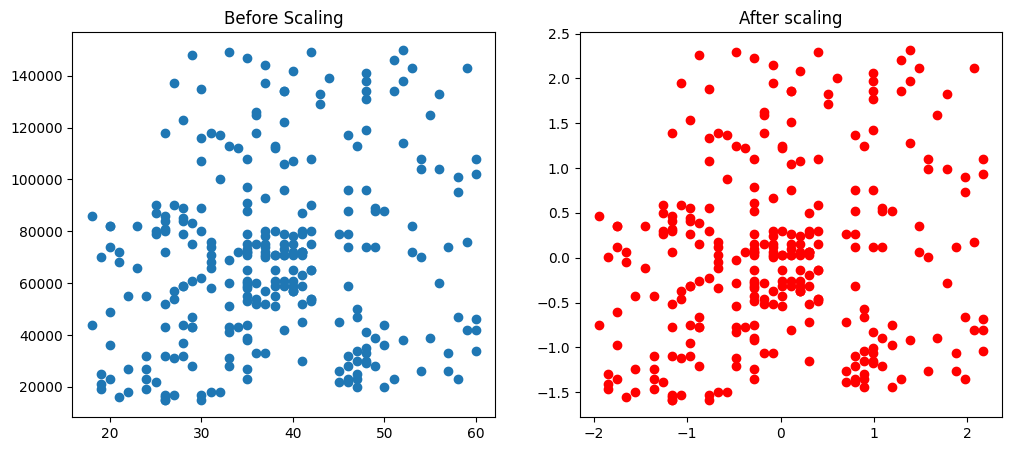

In [56]:
fig,(ax1,ax2) = plt.subplots(ncols=2, figsize=(12,5))
#standard age is 40, standard salary is around 60000
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After scaling")
plt.show()

<Axes: title={'center': 'after scaling'}, xlabel='Age', ylabel='Density'>

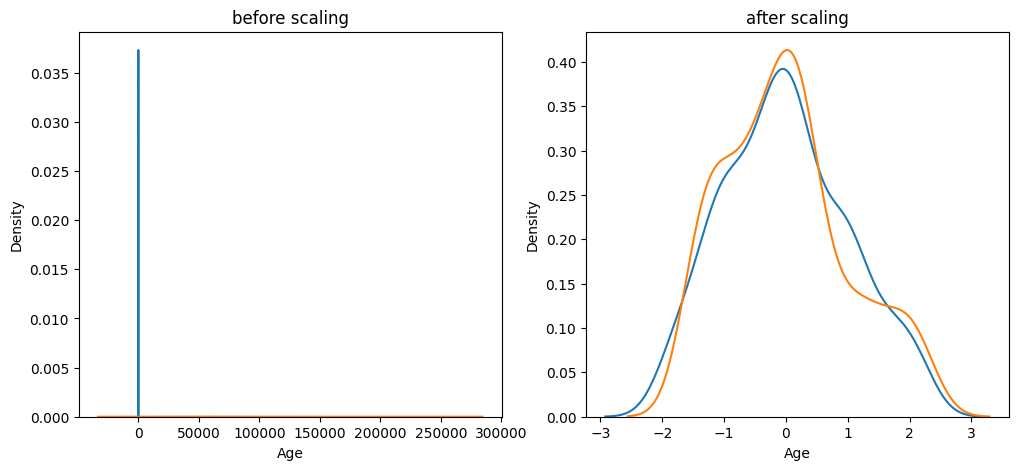

In [92]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
# before scaling
ax1.set_title("before scaling")
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

# after scaling
ax2.set_title("after scaling")
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)

<Axes: title={'center': 'After scaling'}, xlabel='Age', ylabel='Density'>

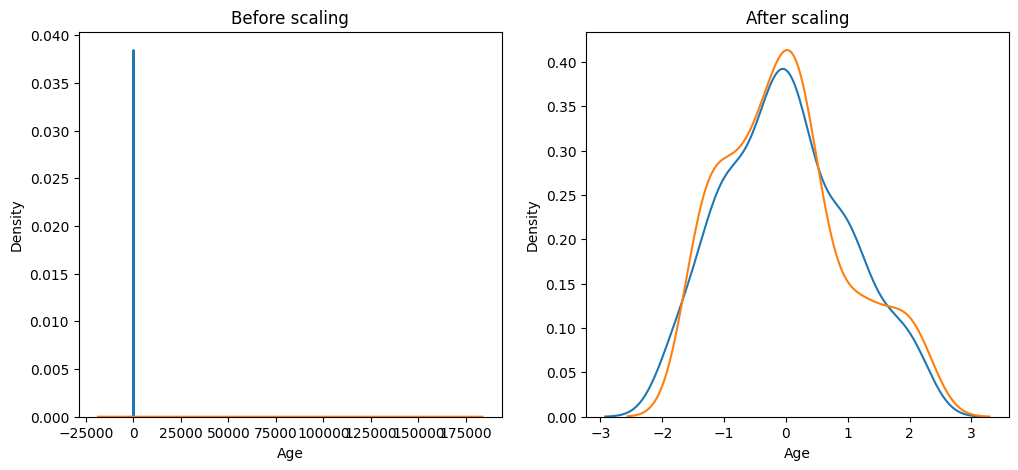

In [57]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title('Before scaling')
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

# after scaling
ax2.set_title('After scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)

<Axes: title={'center': 'after scaling'}, xlabel='Age', ylabel='Density'>

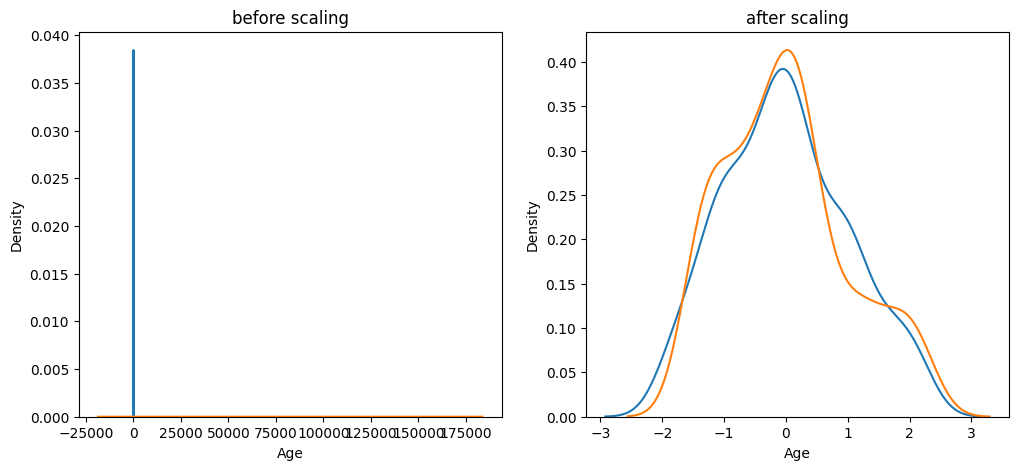

In [58]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

#before scaling
ax1.set_title("before scaling")
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

# after scaling
ax2.set_title("after scaling")
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)

Comparison of distributions

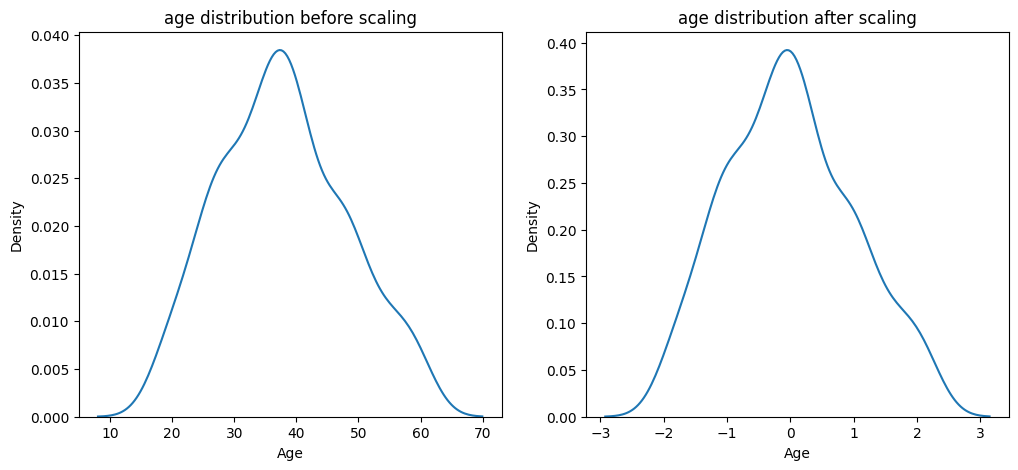

In [59]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title("age distribution before scaling")
sns.kdeplot(X_train['Age'],ax=ax1)

# after scaling
ax2.set_title("age distribution after scaling")
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
plt.show()

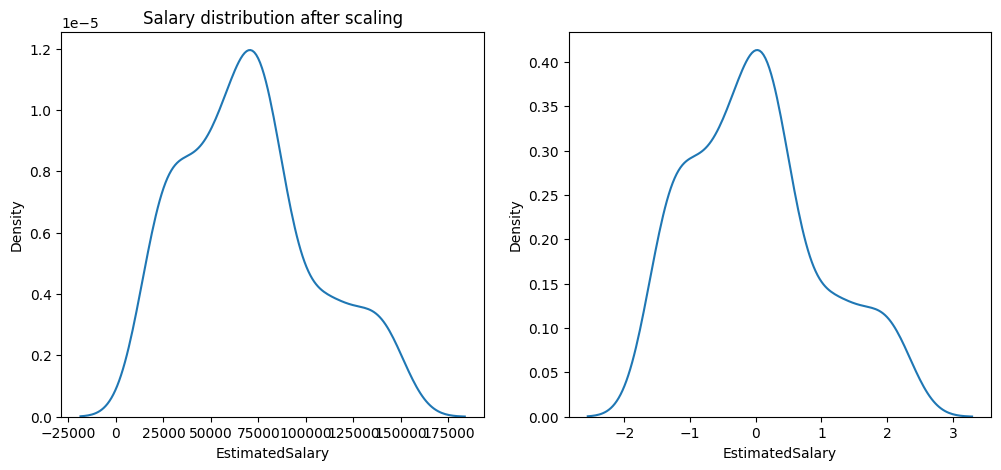

In [60]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title("Salary distribution before scaling")
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)


# after scaling
ax1.set_title("Salary distribution after scaling")
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)
plt.show()

Why is scaling important?

In [61]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [62]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [63]:
y_pred = lr.predict(X_test)
y_pred_scaled=lr_scaled.predict(X_test_scaled)

In [64]:
from sklearn.metrics import accuracy_score

In [65]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [66]:
from sklearn.tree import DecisionTreeClassifier

In [67]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [68]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [69]:
y_pred = dt.predict(X_test)
y_pred_scaled=dt_scaled.predict(X_test_scaled)

In [70]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [71]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


Effect of Outlier

In [77]:
df = pd.concat([
    df,
    pd.DataFrame({
        'Age':[5,90,95],
        'EstimatedSalary':[1000,250000,350000],
        'Purchased':[0,1,1]
        })
],ignore_index=True)

In [78]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


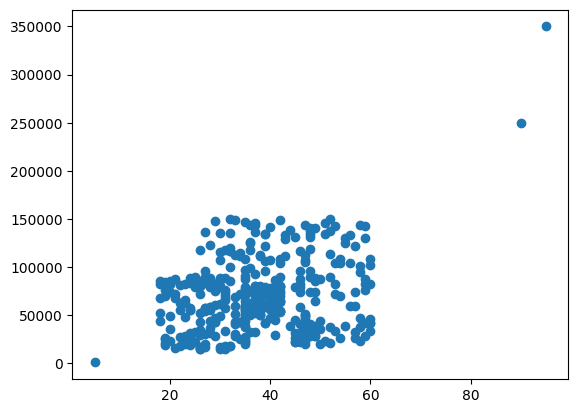

In [81]:
plt.scatter(x=df['Age'],y=df['EstimatedSalary'])

In [84]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Purchased',axis=1),
                                                 df['Purchased'],
                                                 test_size=0.3,
                                                 random_state=0)

In [85]:
X_train.shape

(282, 2)

In [86]:
X_test.shape

(121, 2)

In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [100]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

<Axes: title={'center': 'After scaling'}, xlabel='Age', ylabel='Density'>

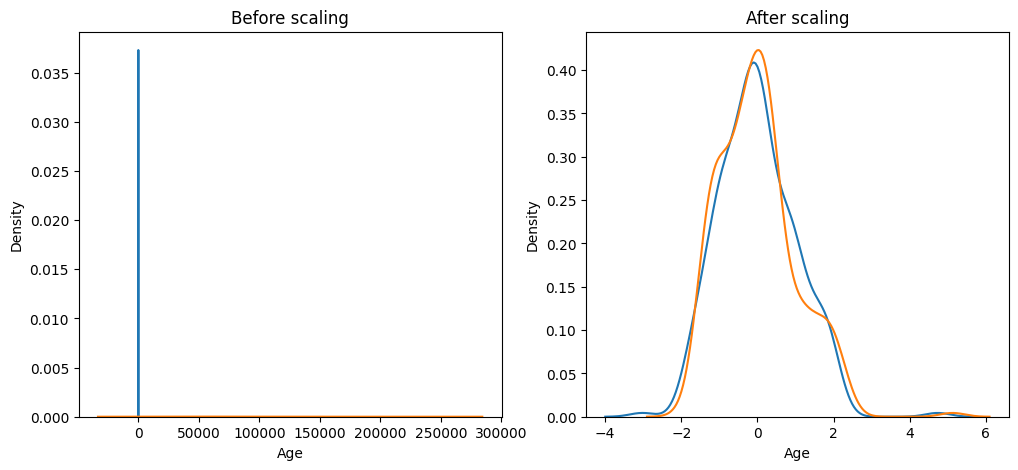

In [103]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

# before scaling
ax1.set_title("Before scaling")
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)

# after scaling
ax2.set_title("After scaling")
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)


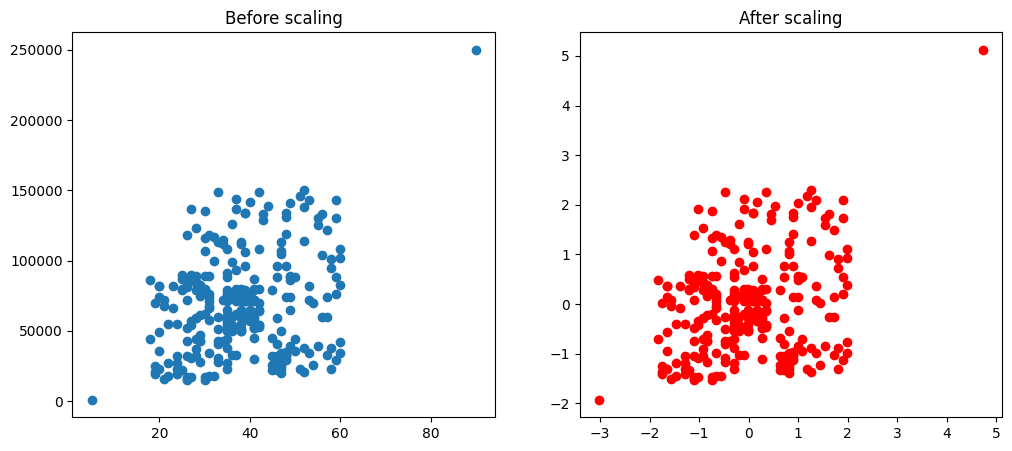

In [108]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title("Before scaling")
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax2.set_title("After scaling")
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color='red')
